<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Logistic%20Regression/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("priyamchoksi/credit-card-transactions-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'credit-card-transactions-dataset' dataset.
Path to dataset files: /kaggle/input/credit-card-transactions-dataset


In [5]:
import pandas as pd

df = pd.read_csv("/kaggle/input/credit-card-transactions-dataset/credit_card_transactions.csv")
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [7]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.100702e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03,4.682575e+04
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02,2.583400e+04
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00,1.001000e+03
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00,2.511400e+04
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00,4.586000e+04
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00,6.831900e+04
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00,9.940300e+04


In [8]:
data = pd.DataFrame(df, columns=['first','trans_date_trans_time','amt','gender','lat','long','is_fraud','state'])
data.head()

,first,trans_date_trans_time,amt,gender,lat,long,is_fraud,state
0,Jennifer,2019-01-01 00:00:18,4.97,F,36.0788,-81.1781,0,NC
1,Stephanie,2019-01-01 00:00:44,107.23,F,48.8878,-118.2105,0,WA
2,Edward,2019-01-01 00:00:51,220.11,M,42.1808,-112.2620,0,ID
3,Jeremy,2019-01-01 00:01:16,45.00,M,46.2306,-112.1138,0,MT
4,Tyler,2019-01-01 00:03:06,41.96,M,38.4207,-79.4629,0,VA


In [9]:
len(data)

1296675

In [10]:
data['state'].unique()

array(['NC', 'WA', 'ID', 'MT', 'VA', 'PA', 'KS', 'TN', 'IA', 'WV', 'FL',
       'CA', 'NM', 'NJ', 'OK', 'IN', 'MA', 'TX', 'WI', 'MI', 'WY', 'HI',
       'NE', 'OR', 'LA', 'DC', 'KY', 'NY', 'MS', 'UT', 'AL', 'AR', 'MD',
       'GA', 'ME', 'AZ', 'MN', 'OH', 'CO', 'VT', 'MO', 'SC', 'NV', 'IL',
       'NH', 'SD', 'AK', 'ND', 'CT', 'RI', 'DE'], dtype=object)

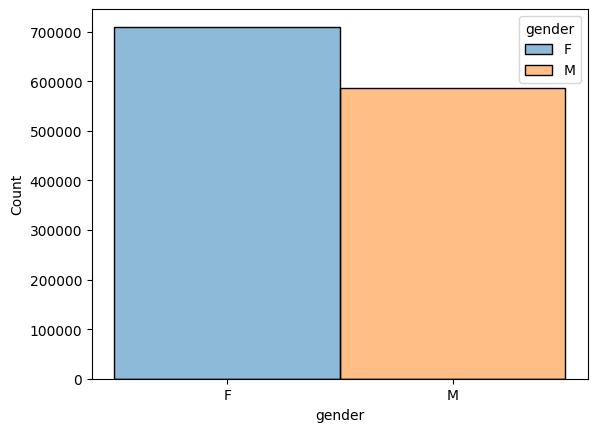

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data, x='gender', hue='gender')
plt.show()

In [12]:
fraud_df = data[data['is_fraud'] == 1]
fraud_df

,first,trans_date_trans_time,amt,gender,lat,long,is_fraud,state
2449,Jason,2019-01-02 01:06:37,281.06,M,35.9946,-81.7266,1,NC
2472,Misty,2019-01-02 01:47:29,11.52,F,29.4400,-98.4590,1,TX
2523,Misty,2019-01-02 03:05:23,276.31,F,29.4400,-98.4590,1,TX
2546,Jason,2019-01-02 03:38:03,7.03,M,35.9946,-81.7266,1,NC
2553,Misty,2019-01-02 03:55:47,275.73,F,29.4400,-98.4590,1,TX
...,...,...,...,...,...,...,...,...
1295399,Ashley,2020-06-21 01:00:08,977.01,F,27.6330,-80.4031,1,FL
1295491,Ashley,2020-06-21 01:53:35,1210.91,F,27.6330,-80.4031,1,FL
1295532,William,2020-06-21 02:16:56,10.24,M,30.4590,-90.9027,1,LA
1295666,Brooke,2020-06-21 03:26:20,21.69,F,31.8599,-102.7413,1,TX


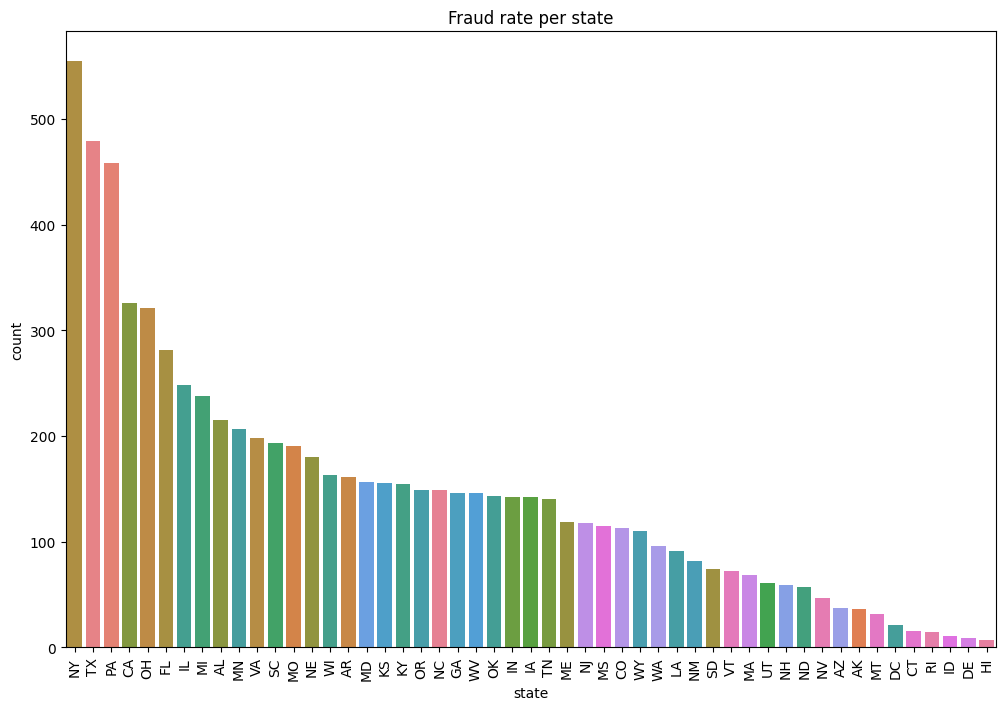

In [13]:
plt.figure(figsize=(12,8))
plt.title("Fraud rate per state")
sns.countplot(fraud_df, x='state', order=fraud_df['state'].value_counts().index, hue='state')
plt.xticks(rotation=90)
plt.show()

In [14]:
data[data['is_fraud'] == 1]

,first,trans_date_trans_time,amt,gender,lat,long,is_fraud,state
2449,Jason,2019-01-02 01:06:37,281.06,M,35.9946,-81.7266,1,NC
2472,Misty,2019-01-02 01:47:29,11.52,F,29.4400,-98.4590,1,TX
2523,Misty,2019-01-02 03:05:23,276.31,F,29.4400,-98.4590,1,TX
2546,Jason,2019-01-02 03:38:03,7.03,M,35.9946,-81.7266,1,NC
2553,Misty,2019-01-02 03:55:47,275.73,F,29.4400,-98.4590,1,TX
...,...,...,...,...,...,...,...,...
1295399,Ashley,2020-06-21 01:00:08,977.01,F,27.6330,-80.4031,1,FL
1295491,Ashley,2020-06-21 01:53:35,1210.91,F,27.6330,-80.4031,1,FL
1295532,William,2020-06-21 02:16:56,10.24,M,30.4590,-90.9027,1,LA
1295666,Brooke,2020-06-21 03:26:20,21.69,F,31.8599,-102.7413,1,TX


In [15]:
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])
data.head()

,first,trans_date_trans_time,amt,gender,lat,long,is_fraud,state
0,Jennifer,2019-01-01 00:00:18,4.97,F,36.0788,-81.1781,0,NC
1,Stephanie,2019-01-01 00:00:44,107.23,F,48.8878,-118.2105,0,WA
2,Edward,2019-01-01 00:00:51,220.11,M,42.1808,-112.2620,0,ID
3,Jeremy,2019-01-01 00:01:16,45.00,M,46.2306,-112.1138,0,MT
4,Tyler,2019-01-01 00:03:06,41.96,M,38.4207,-79.4629,0,VA


In [16]:
data['hour'] = data['trans_date_trans_time'].dt.hour
data.head()

,first,trans_date_trans_time,amt,gender,lat,long,is_fraud,state,hour
0,Jennifer,2019-01-01 00:00:18,4.97,F,36.0788,-81.1781,0,NC,0
1,Stephanie,2019-01-01 00:00:44,107.23,F,48.8878,-118.2105,0,WA,0
2,Edward,2019-01-01 00:00:51,220.11,M,42.1808,-112.2620,0,ID,0
3,Jeremy,2019-01-01 00:01:16,45.00,M,46.2306,-112.1138,0,MT,0
4,Tyler,2019-01-01 00:03:06,41.96,M,38.4207,-79.4629,0,VA,0


In [17]:
data['day_of_the_week'] = data['trans_date_trans_time'].dt.day_of_week
data.head()

,first,trans_date_trans_time,amt,gender,lat,long,is_fraud,state,hour,day_of_the_week
0,Jennifer,2019-01-01 00:00:18,4.97,F,36.0788,-81.1781,0,NC,0,1
1,Stephanie,2019-01-01 00:00:44,107.23,F,48.8878,-118.2105,0,WA,0,1
2,Edward,2019-01-01 00:00:51,220.11,M,42.1808,-112.2620,0,ID,0,1
3,Jeremy,2019-01-01 00:01:16,45.00,M,46.2306,-112.1138,0,MT,0,1
4,Tyler,2019-01-01 00:03:06,41.96,M,38.4207,-79.4629,0,VA,0,1


In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoded_gender = encoder.fit_transform(data['gender'])

In [19]:
encoded_gender

array([0, 0, 1, ..., 1, 1, 1])

In [20]:
data['e_gender'] = encoded_gender
data.head()

,first,trans_date_trans_time,amt,gender,lat,long,is_fraud,state,hour,day_of_the_week,e_gender
0,Jennifer,2019-01-01 00:00:18,4.97,F,36.0788,-81.1781,0,NC,0,1,0
1,Stephanie,2019-01-01 00:00:44,107.23,F,48.8878,-118.2105,0,WA,0,1,0
2,Edward,2019-01-01 00:00:51,220.11,M,42.1808,-112.2620,0,ID,0,1,1
3,Jeremy,2019-01-01 00:01:16,45.00,M,46.2306,-112.1138,0,MT,0,1,1
4,Tyler,2019-01-01 00:03:06,41.96,M,38.4207,-79.4629,0,VA,0,1,1


In [21]:
features = ['amt','lat','long','hour', 'day_of_the_week', 'e_gender']
labels = ['is_fraud']
X = data[features]
y = data[labels]
X

,amt,lat,long,hour,day_of_the_week,e_gender
0,4.97,36.0788,-81.1781,0,1,0
1,107.23,48.8878,-118.2105,0,1,0
2,220.11,42.1808,-112.2620,0,1,1
3,45.00,46.2306,-112.1138,0,1,1
4,41.96,38.4207,-79.4629,0,1,1
...,...,...,...,...,...,...
1296670,15.56,37.7175,-112.4777,12,6,1
1296671,51.70,39.2667,-77.5101,12,6,1
1296672,105.93,32.9396,-105.8189,12,6,1
1296673,74.90,43.3526,-102.5411,12,6,1


In [26]:
y = y.values.ravel()
y

array([0, 0, 0, ..., 0, 0, 0])

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
len(X_train), len(X_test)

(1037340, 259335)

In [28]:
y_train

array([0, 0, 0, ..., 0, 0, 0])

In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
model.fit(X_train, y_train.ravel())

RandomForestClassifier(class_weight='balanced', random_state=42)

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cr = classification_report(y_pred, y_test)
cm = confusion_matrix(y_pred, y_test)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    258515
           1       0.46      0.83      0.59       820

    accuracy                           1.00    259335
   macro avg       0.73      0.91      0.79    259335
weighted avg       1.00      1.00      1.00    259335



In [31]:
print(cm)

[[257708    807]
 [   140    680]]


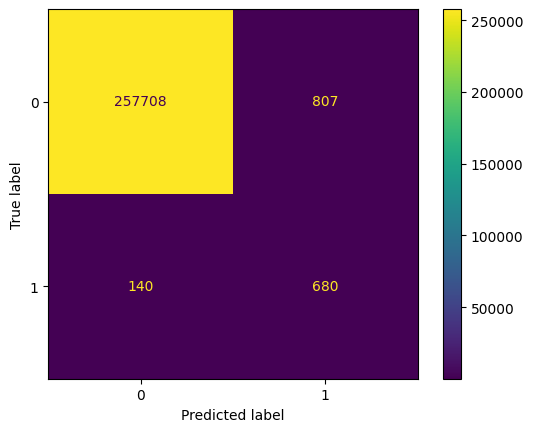

In [32]:
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [33]:
model.feature_importances_

array([0.64283107, 0.05605596, 0.05455233, 0.22371831, 0.01793125,
       0.00491109])